<a href="https://colab.research.google.com/github/Priyanshu8945/ML_project/blob/main/Dynamic_with%20fulkerson_algo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Loading data and building the network...
Network built with 48 nodes and 96 edges.

Step 2: Computing s-t Min-Cuts for all pairs... (Please wait)

TOP 10 CRUCIAL EDGES (GLOBAL VULNERABILITY RANKING)
Rank  1: Edge (30, 41) | Importance Score: 78.0000
Rank  2: Edge (23, 7) | Importance Score: 65.0000
Rank  3: Edge (1, 9) | Importance Score: 51.0000
Rank  4: Edge (14, 28) | Importance Score: 51.0000
Rank  5: Edge (46, 35) | Importance Score: 51.0000
Rank  6: Edge (17, 1) | Importance Score: 51.0000
Rank  7: Edge (44, 5) | Importance Score: 50.5000
Rank  8: Edge (41, 14) | Importance Score: 50.0000
Rank  9: Edge (46, 48) | Importance Score: 50.0000
Rank 10: Edge (5, 45) | Importance Score: 49.5000

Report Sample: Cut set to disconnect (1, 35): [(46, 35)]


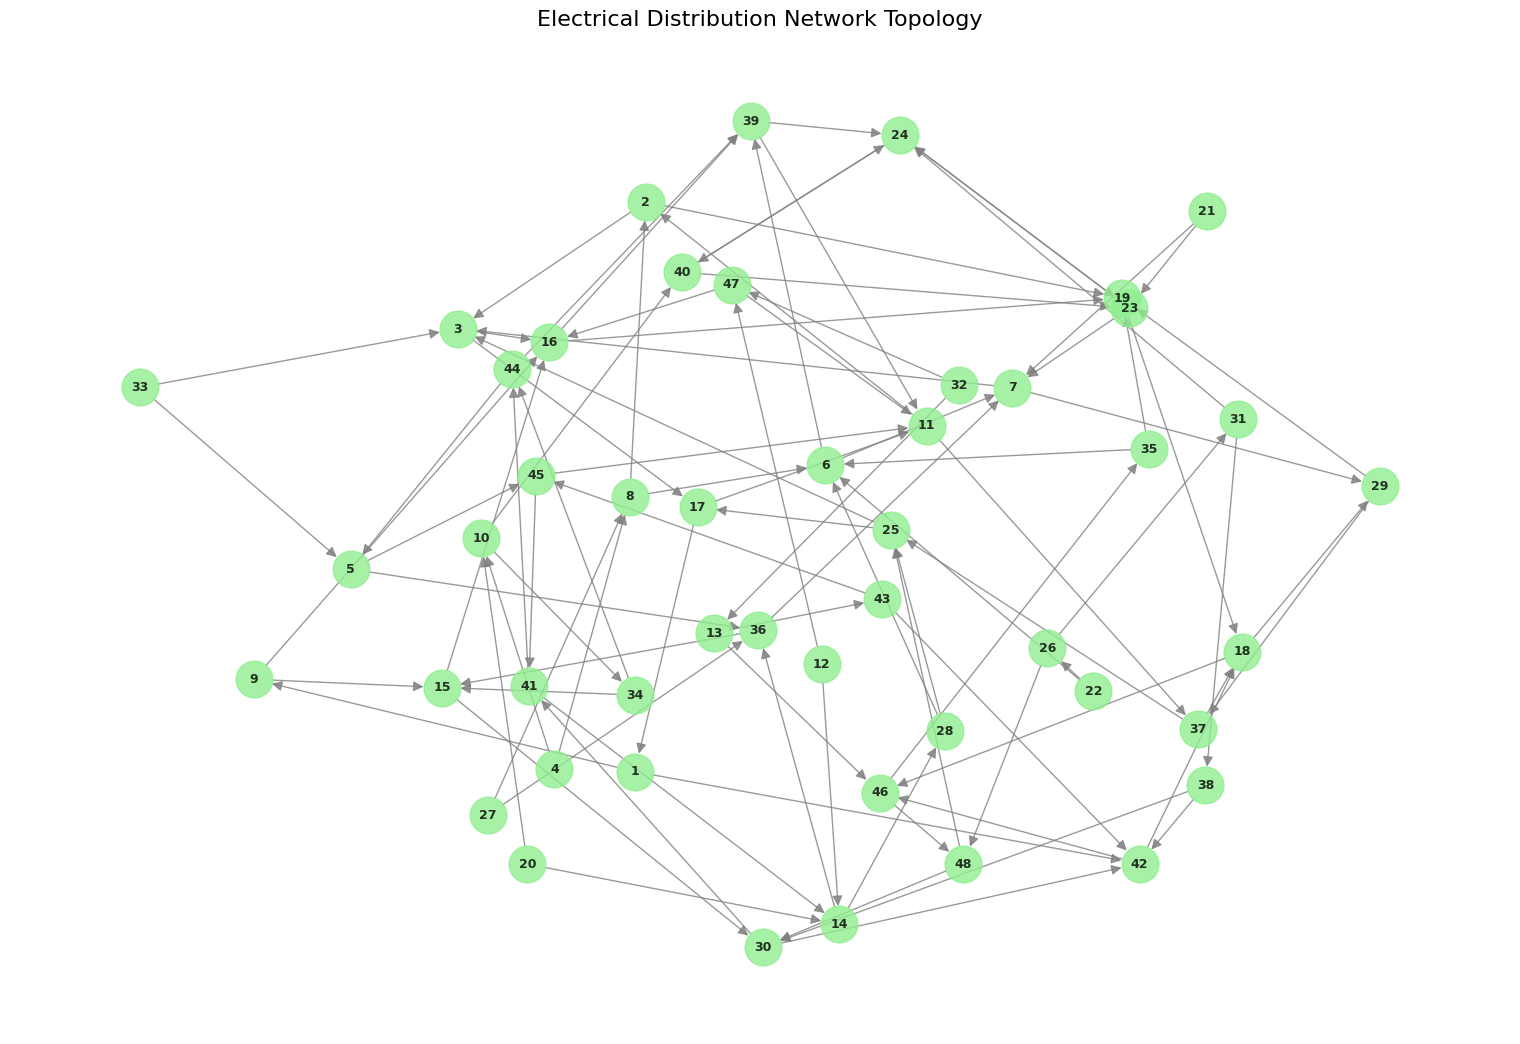

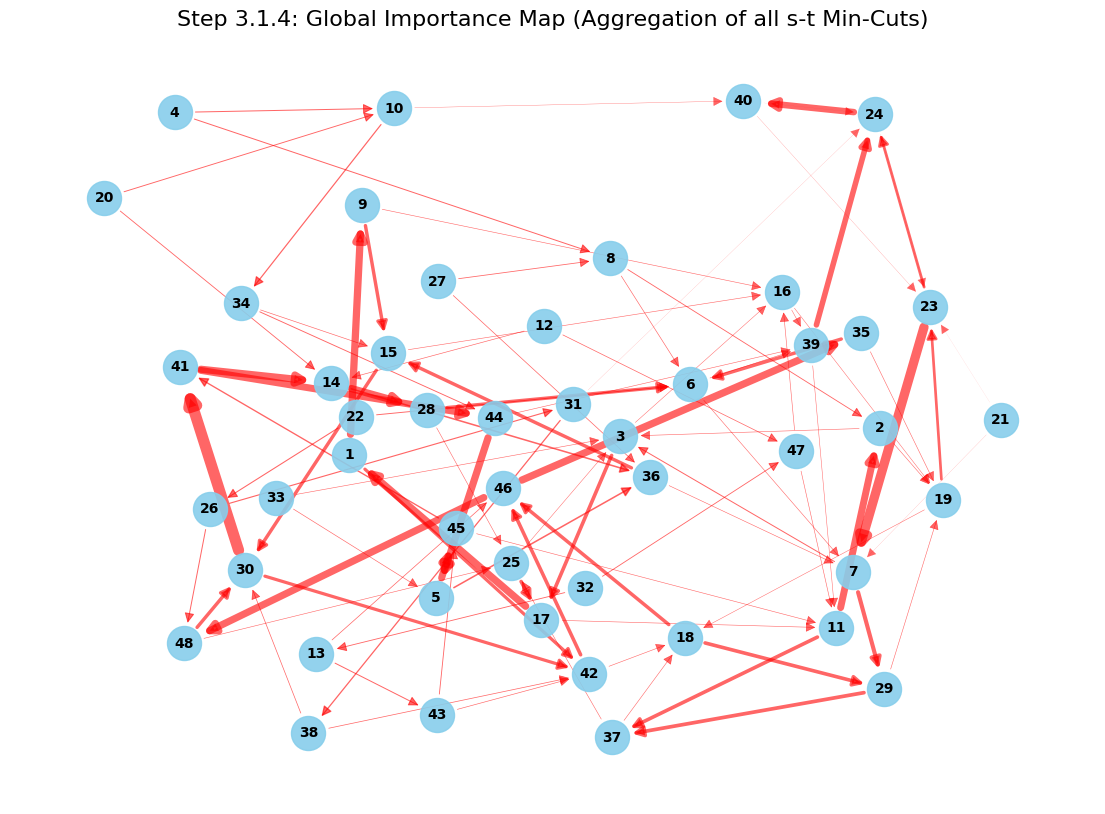

In [ ]:
import pandas as pd
import networkx as nx
import ast
import rmatplotlib.pyplot as plt
from itertools import permutations
from collections import defaultdict

# ---------------------------------------------------------
# 1. DATA LOADING & GRAPH CONSTRUCTION
# ---------------------------------------------------------
print("Step 1: Loading data and building the network...")
df = pd.read_csv('Dynamic_Distribution_Network_PowerFlow.csv')

# Use unique topology only
topology = df.drop_duplicates(subset=['node_id'])

G = nx.DiGraph()
for _, row in topology.iterrows():
    u = row['node_id']
    try:
        # Convert string "[42, 9]" to a Python list
        v_list = ast.literal_eval(row['connected_nodes'])
        for v in v_list:
            # Capacity=1 treats the problem as 'how many wires to cut'
            G.add_edge(u, v, capacity=1.0)
    except (ValueError, SyntaxError):
        continue


nodes = list(G.nodes())
print(f"Network built with {len(nodes)} nodes and {G.number_of_edges()} edges.")

# ---------------------------------------------------------
# 2. MIN-CUT ANALYSIS (Section 3.1.1 - 3.1.4 of PDF)
# ---------------------------------------------------------
# We will store the actual cut-set edges for every pair (as requested)
# and tally the frequency for the global ranking.
all_cut_sets = {}
edge_importance_tally = defaultdict(float)

print("\nStep 2: Computing s-t Min-Cuts for all pairs... (Please wait)")

# permutations(nodes, 2) creates every possible pair (Source s, Target t)
for s, t in permutations(nodes, 2):
    try:
        # Step 3.1.1: Compute Min-Cut using Edmonds-Karp logic
        cut_value, partition = nx.minimum_cut(G, s, t)

        # If cut_value is 0, nodes are naturally disconnected
        if cut_value == 0:
            continue

        reachable, non_reachable = partition

        # Identify which edges actually cross the cut boundary
        current_cut_edges = []
        for u, v in G.edges():
            if u in reachable and v in non_reachable:
                current_cut_edges.append((u, v))

                # Step 3.1.3 & 3.1.4: Frequency-based importance tally
                # We weight by 1/cut_value (Smaller cuts = higher importance)
                edge_importance_tally[(u, v)] += (1.0 / cut_value)

        # Store the specific cut set for this pair (for your report)
        all_cut_sets[(s, t)] = current_cut_edges

    except nx.NetworkXNoPath:
        continue

# ---------------------------------------------------------
# 3. RESULTS & RANKING
# ---------------------------------------------------------
# Sort edges by their aggregated importance score
ranked_edges = sorted(edge_importance_tally.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*50)
print("TOP 10 CRUCIAL EDGES (GLOBAL VULNERABILITY RANKING)")
print("="*50)
for i, (edge, score) in enumerate(ranked_edges[:10]):
    print(f"Rank {i+1:2}: Edge {edge} | Importance Score: {score:.4f}")

# Example of looking up a stored cut for a specific pair
example_pair = (nodes[0], nodes[-1]) # First and last node
if example_pair in all_cut_sets:
    print(f"\nReport Sample: Cut set to disconnect {example_pair}: {all_cut_sets[example_pair]}")
plt.figure(figsize=(15, 10))

# Use spring_layout to space out the nodes naturally
pos = nx.spring_layout(G, k=0.5, seed=42)

# 5. Draw the graph
nx.draw(G, pos,
        with_labels=True,
        node_color='lightgreen',
        node_size=700,
        edge_color='gray',
        arrowsize=15,
        font_size=9,
        font_weight='bold',
        alpha=0.8)

plt.title("Electrical Distribution Network Topology", fontsize=16)
plt.savefig('network_topology.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

# Normalize scores for visual line thickness
max_score = max(edge_importance_tally.values()) if edge_importance_tally else 1
edge_widths = [(edge_importance_tally.get(edge, 0) / max_score) * 8 for edge in G.edges()]

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='skyblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw the edges with thickness based on importance
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='red',
                       alpha=0.6, arrowsize=15, min_source_margin=15, min_target_margin=15)

plt.title("Step 3.1.4: Global Importance Map (Aggregation of all s-t Min-Cuts)", fontsize=16)
plt.axis('off')
plt.savefig('global_importance_map.png', dpi=300, bbox_inches='tight')
plt.show()

TOP 10 EDGES BY BETWEENNESS CENTRALITY
Rank  1: Edge (30, 41) | Centrality Score: 0.1260
Rank  2: Edge (46, 48) | Centrality Score: 0.1031
Rank  3: Edge (18, 46) | Centrality Score: 0.0969
Rank  4: Edge (17, 1) | Centrality Score: 0.0892
Rank  5: Edge (48, 30) | Centrality Score: 0.0818
Rank  6: Edge (41, 14) | Centrality Score: 0.0744
Rank  7: Edge (15, 30) | Centrality Score: 0.0711
Rank  8: Edge (41, 44) | Centrality Score: 0.0677
Rank  9: Edge (3, 17) | Centrality Score: 0.0650
Rank 10: Edge (19, 18) | Centrality Score: 0.0627


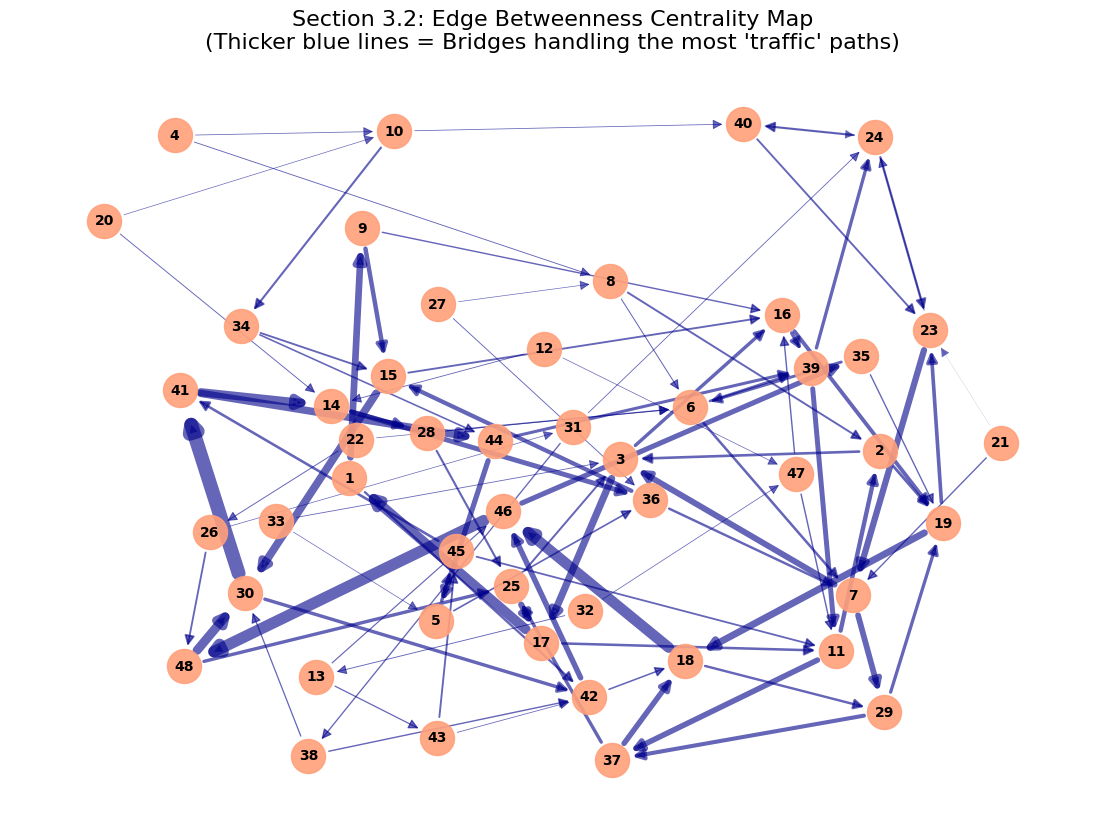

In [ ]:
import pandas as pd
import networkx as nx
import ast
import matplotlib.pyplot as plt

# 1. Build the graph (using the same logic for consistency)
df = pd.read_csv('Dynamic_Distribution_Network_PowerFlow.csv')
topology = df.drop_duplicates(subset=['node_id'])

G = nx.DiGraph()
for _, row in topology.iterrows():
    u = row['node_id']
    try:
        v_list = ast.literal_eval(row['connected_nodes'])
        for v in v_list:
            G.add_edge(u, v)
    except:
        continue

# 2. Calculate Edge Betweenness Centrality (Section 3.2 of PDF)
# This calculates: (Number of shortest paths passing through edge) / (Total shortest paths)
edge_centrality = nx.edge_betweenness_centrality(G)

# 3. Rank the edges by Centrality
ranked_centrality = sorted(edge_centrality.items(), key=lambda x: x[1], reverse=True)

print("="*50)
print("TOP 10 EDGES BY BETWEENNESS CENTRALITY")
print("="*50)
for i, (edge, score) in enumerate(ranked_centrality[:10]):
    print(f"Rank {i+1:2}: Edge {edge} | Centrality Score: {score:.4f}")

# 4. Plot the Centrality Graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)

# Normalize scores for visual line thickness
max_bc = max(edge_centrality.values()) if edge_centrality else 1
bc_widths = [(edge_centrality.get(edge, 0) / max_bc) * 10 for edge in G.edges()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightsalmon', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw edges (Thicker = Higher Centrality)
nx.draw_networkx_edges(G, pos, width=bc_widths, edge_color='darkblue',
                       alpha=0.6, arrowsize=15, min_source_margin=15, min_target_margin=15)

plt.title("Section 3.2: Edge Betweenness Centrality Map\n(Thicker blue lines = Bridges handling the most 'traffic' paths)", fontsize=16)
plt.axis('off')
plt.savefig("BC")
plt.show()

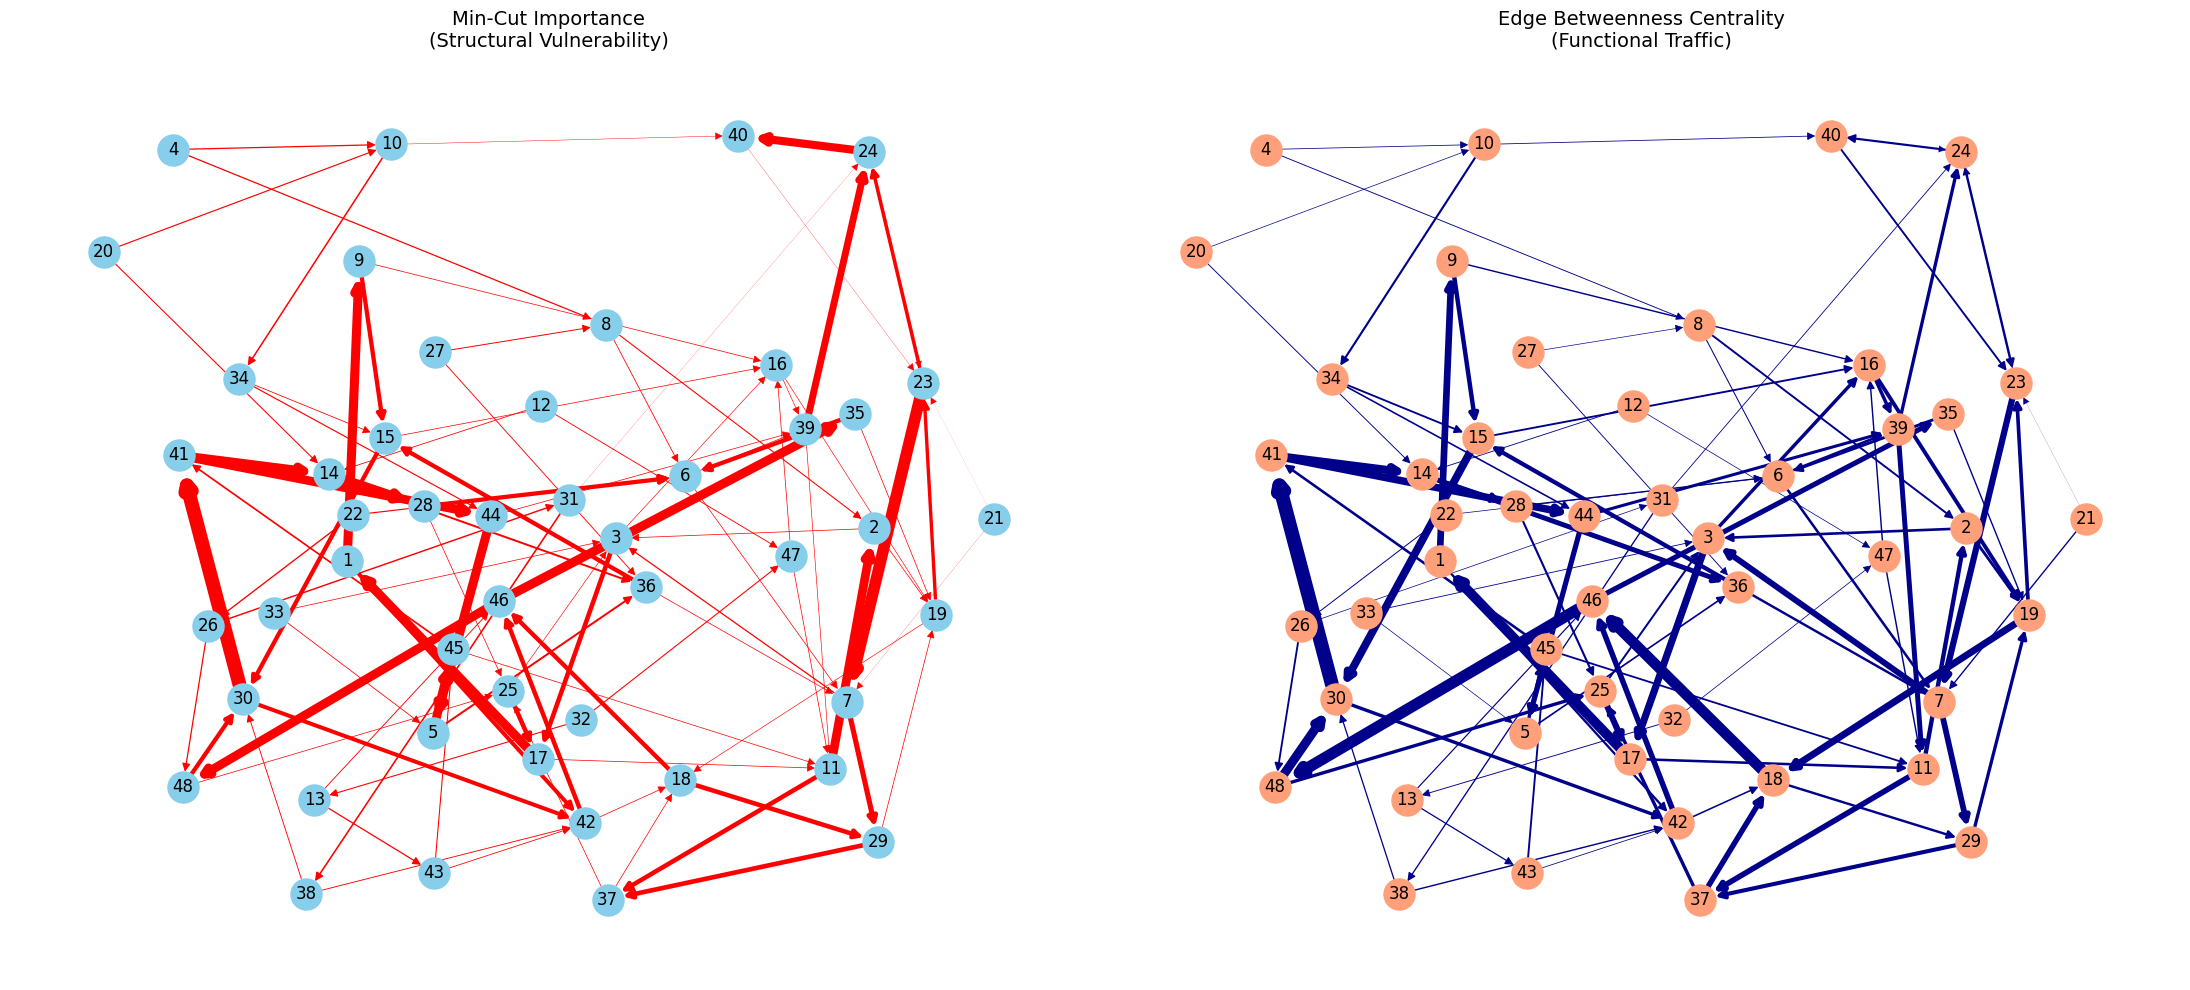

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# --- Plot 1: Min-Cut (Structural) ---
max_mincut = max(edge_importance_tally.values()) if edge_importance_tally else 1
widths_mincut = [(edge_importance_tally.get(e, 0) / max_mincut) * 10 for e in G.edges()]

nx.draw(G, pos, ax=ax1, with_labels=True, node_color='skyblue',
        width=widths_mincut, edge_color='red', node_size=500, arrowsize=12)
ax1.set_title("Min-Cut Importance\n(Structural Vulnerability)", fontsize=14)

# --- Plot 2: Betweenness (Functional) ---
max_bc = max(edge_centrality.values()) if edge_centrality else 1
widths_bc = [(edge_centrality.get(e, 0) / max_bc) * 10 for e in G.edges()]

nx.draw(G, pos, ax=ax2, with_labels=True, node_color='lightsalmon',
        width=widths_bc, edge_color='darkblue', node_size=500, arrowsize=12)
ax2.set_title("Edge Betweenness Centrality\n(Functional Traffic)", fontsize=14)

plt.tight_layout()
plt.savefig("mincut vs BC")
plt.show()

In [ ]:
import scipy.stats as stats

# Convert dictionaries to a sorted Series for comparison
edges = sorted(list(G.edges()))
scores_mincut = [edge_importance_tally.get(e, 0) for e in edges]
scores_bc = [edge_centrality.get(e, 0) for e in edges]

# Calculate Spearman Rank Correlation (checks if the rankings are in the same order)
correlation, p_value = stats.spearmanr(scores_mincut, scores_bc)

# Find the edges with the biggest difference in importance
diffs = []
for i, edge in enumerate(edges):
    # Normalize scores first to compare 0-1
    norm_mincut = scores_mincut[i] / max(scores_mincut) if max(scores_mincut) > 0 else 0
    norm_bc = scores_bc[i] / max(scores_bc) if max(scores_bc) > 0 else 0
    diffs.append((edge, abs(norm_mincut - norm_bc)))

# Sort by biggest difference
biggest_diffs = sorted(diffs, key=lambda x: x[1], reverse=True)

print(f"Rank Correlation (Spearman): {correlation:.4f}")
print("-" * 30)
print("Top 10 Edges where the two methods DISAGREE most:")
for edge, diff in biggest_diffs[:10]:
    print(f"Edge {edge}: Difference Magnitude = {diff:.4f}")

Rank Correlation (Spearman): 0.4733
------------------------------
Top 10 Edges where the two methods DISAGREE most:
Edge (18, 46): Difference Magnitude = 0.4548
Edge (19, 18): Difference Magnitude = 0.4527
Edge (24, 40): Difference Magnitude = 0.4285
Edge (5, 45): Difference Magnitude = 0.3931
Edge (23, 7): Difference Magnitude = 0.3839
Edge (14, 28): Difference Magnitude = 0.3480
Edge (48, 30): Difference Magnitude = 0.3415
Edge (7, 3): Difference Magnitude = 0.3410
Edge (37, 18): Difference Magnitude = 0.3406
Edge (11, 2): Difference Magnitude = 0.3136


In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# 1. Prepare the comparison dataset
edges = list(G.edges())
comp_list = []

for e in edges:
    comp_list.append({
        "Edge": str(e),
        "Min-Cut_Structural": edge_importance_tally.get(e, 0),
        "Betweenness_Functional": edge_centrality.get(e, 0)
    })

df_final = pd.DataFrame(comp_list)

# 2. Normalization (Required for an accurate Pearson Calculation)
# This scales values to 0-1 so we can compare the "magnitude" of the scores
for col in ["Min-Cut_Structural", "Betweenness_Functional"]:
    max_val = df_final[col].max()
    min_val = df_final[col].min()
    if max_val != min_val:
        df_final[col] = (df_final[col] - min_val) / (max_val - min_val)

# 3. Dual Correlation Calculation
# Pearson: Checks for a direct linear relationship (magnitude vs magnitude)
pearson_corr, _ = stats.pearsonr(df_final["Min-Cut_Structural"], df_final["Betweenness_Functional"])

# Spearman: Checks for a ranked relationship (order vs order)
spearman_corr, _ = stats.spearmanr(df_final["Min-Cut_Structural"], df_final["Betweenness_Functional"])

# 4. Global Criticality Score (Average of normalized importance)
df_final["Global_Criticality"] = (df_final["Min-Cut_Structural"] + df_final["Betweenness_Functional"]) / 2
df_final = df_final.sort_values(by="Global_Criticality", ascending=False).reset_index(drop=True)

# 5. FINAL TECHNICAL REPORT
print("="*65)
print("             ADVANCED GRID CONNECTIVITY ANALYSIS             ")
print("="*65)
print(f"{'Metric':<30} | {'Value':<10}")
print("-" * 45)
print(f"{'Pearson Correlation (Linear)':<30} | {pearson_corr:.4f}")
print(f"{'Spearman Correlation (Rank)':<30} | {spearman_corr:.4f}")
print("-" * 45)

print("\n--- TOP 5 CRITICAL ASSETS (COMBINED ANALYSIS) ---")
print(df_final[['Edge', 'Global_Criticality']].head(5))

print("\n" + "="*65)
print("STATISTICAL INTERPRETATION & CONCLUSION")
print("="*65)

# Conclusion Logic based on the difference between Pearson and Spearman
if spearman_corr > 0.8 and pearson_corr > 0.8:
    print("CONCLUSION: Strong Linear Alignment. The network is HIGHLY RADIAL.")
    print("INSIGHT: The busiest lines are precisely the most vulnerable structural bottlenecks.")
elif spearman_corr > pearson_corr + 0.2:
    print("CONCLUSION: Non-Linear Monotonic Relationship.")
    print("INSIGHT: The 'Order' of importance matches, but the 'Magnitude' of flow is uneven.")
    print("          This suggests a semi-radial grid with some heavy-load hubs.")
elif spearman_corr < 0.5:
    print("CONCLUSION: Low Correlation. The network has MESH/LOOPED redundancy.")
    print("INSIGHT: High-traffic edges are NOT necessarily structural risks.")

print("\nSTRATEGIC RECOMMENDATION:")
top_edge = df_final.iloc[0]['Edge']
print(f"-> Prioritize maintenance on {top_edge}. It holds the highest composite risk.")
print("="*65)

# Save the detailed breakdown
df_final.to_csv("advanced_edge_vulnerability_report.csv", index=False)

             ADVANCED GRID CONNECTIVITY ANALYSIS             
Metric                         | Value     
---------------------------------------------
Pearson Correlation (Linear)   | 0.6958
Spearman Correlation (Rank)    | 0.4733
---------------------------------------------

--- TOP 5 CRITICAL ASSETS (COMBINED ANALYSIS) ---
       Edge  Global_Criticality
0  (30, 41)            1.000000
1  (46, 48)            0.727508
2   (17, 1)            0.678082
3   (23, 7)            0.637923
4  (41, 14)            0.612552

STATISTICAL INTERPRETATION & CONCLUSION
CONCLUSION: Low Correlation. The network has MESH/LOOPED redundancy.
INSIGHT: High-traffic edges are NOT necessarily structural risks.

STRATEGIC RECOMMENDATION:
-> Prioritize maintenance on (30, 41). It holds the highest composite risk.


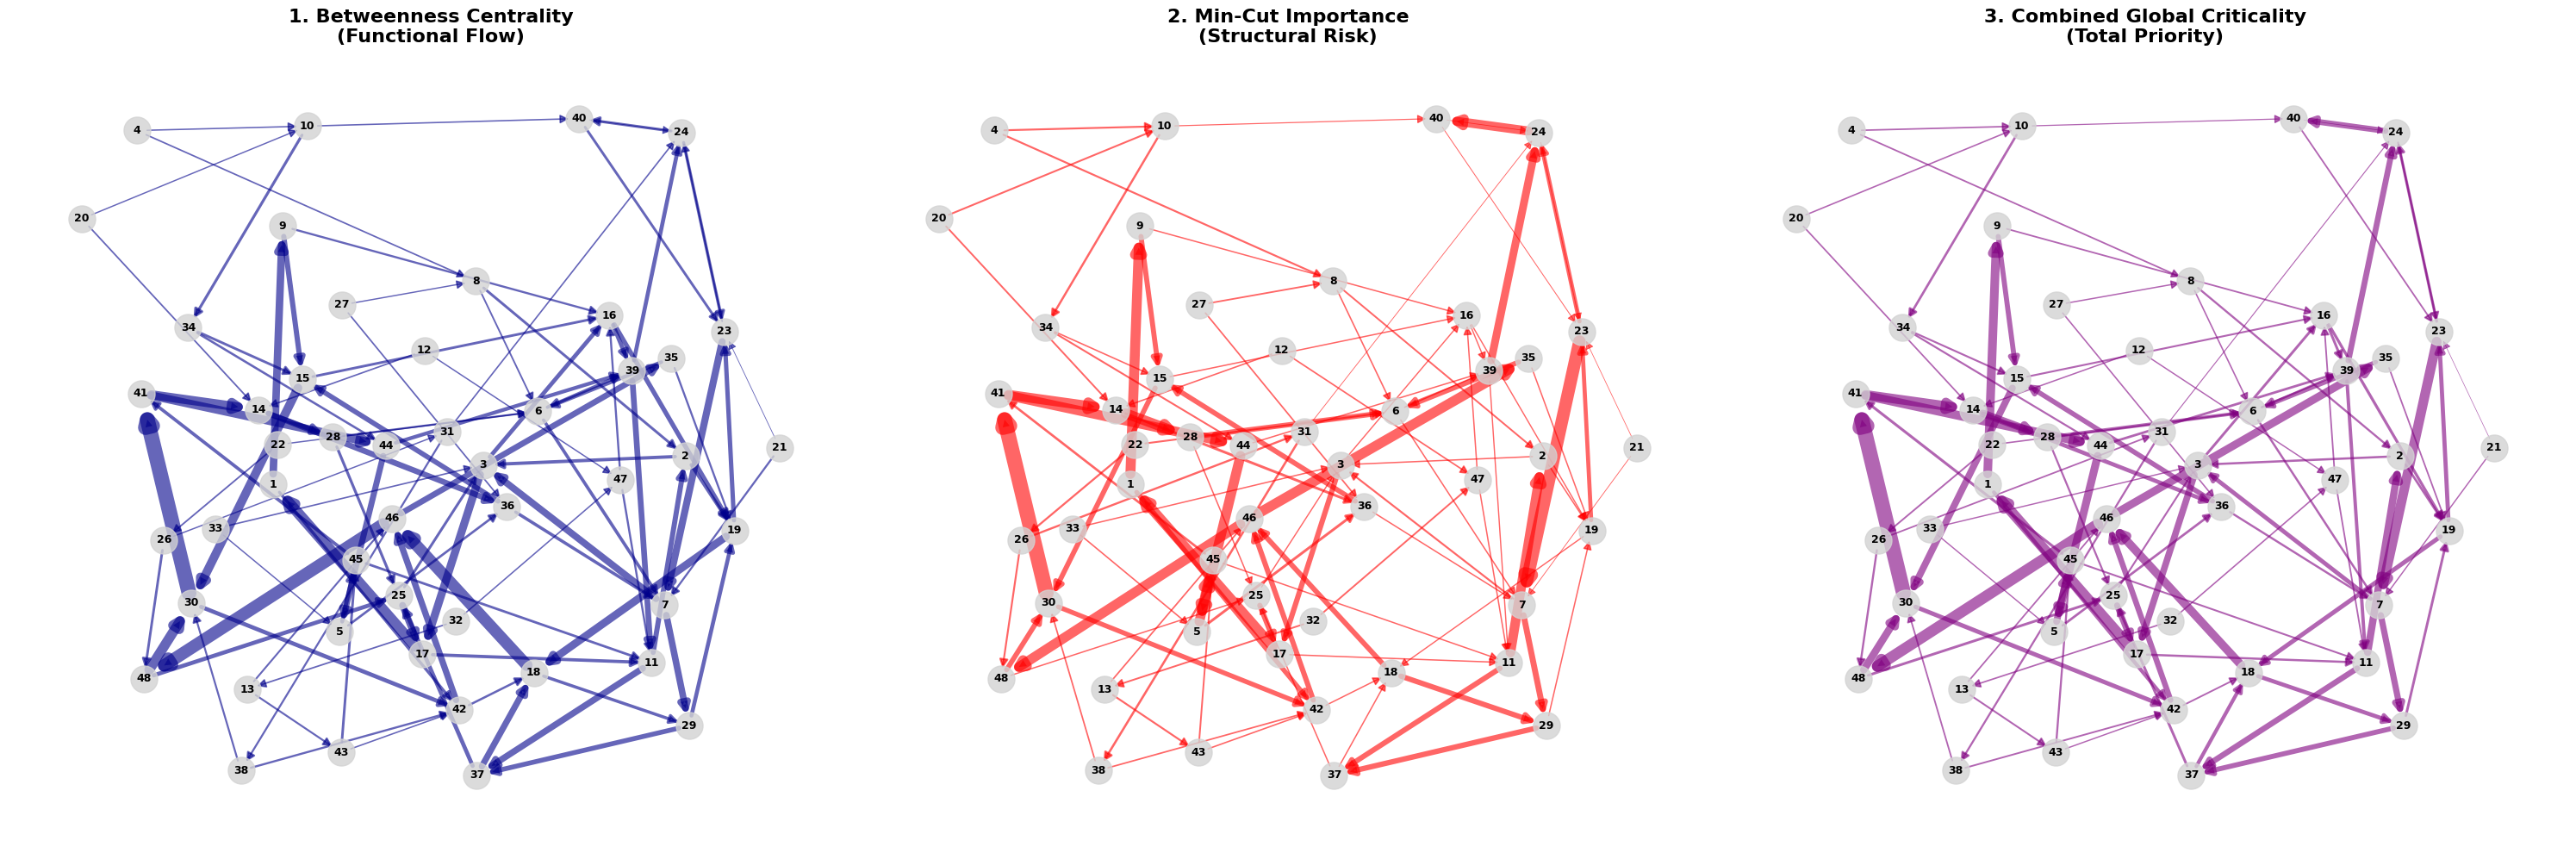

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. Prepare the Combined Score Dictionary for plotting
# (Mapping the strings in df_final back to edge tuples)
combined_scores = {}
for _, row in df_final.iterrows():
    # Convert string "(1, 9)" back to tuple (1, 9)
    edge_tuple = eval(row['Edge'])
    combined_scores[edge_tuple] = row['Global_Criticality']

# 2. Setup the Plotting Figure
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
titles = ["1. Betweenness Centrality\n(Functional Flow)",
          "2. Min-Cut Importance\n(Structural Risk)",
          "3. Combined Global Criticality\n(Total Priority)"]

# Use a consistent layout for all three graphs
# Note: 'pos' should already be defined from previous cells
if 'pos' not in locals():
    pos = nx.spring_layout(G, seed=42)

# Metric lists and colors for each subplot
metrics = [edge_centrality, edge_importance_tally, combined_scores]
edge_colors = ['darkblue', 'red', 'purple']

for i, ax in enumerate(axes):
    current_metric = metrics[i]
    color = edge_colors[i]

    # Normalize current metric for edge widths (scale 1 to 12)
    max_val = max(current_metric.values()) if current_metric else 1
    widths = [(current_metric.get(e, 0) / max_val) * 12 + 0.5 for e in G.edges()]

    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=500, node_color='lightgray', alpha=0.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight='bold')

    # Draw Edges
    nx.draw_networkx_edges(G, pos, ax=ax, width=widths,
                           edge_color=color, alpha=0.6, arrowsize=15)

    ax.set_title(titles[i], fontsize=16, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig("combined_graphs")
plt.show()

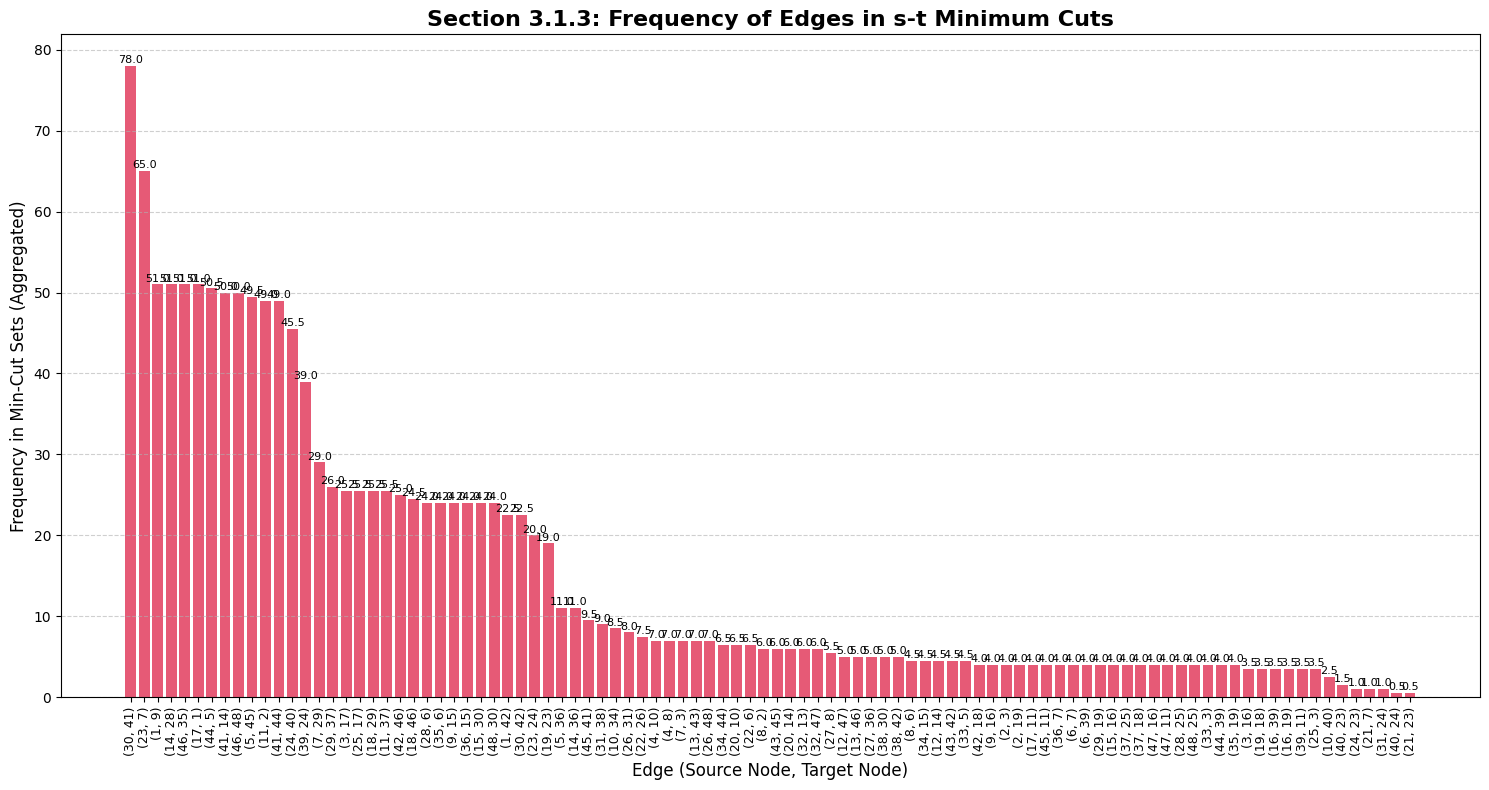

In [ ]:
import matplotlib.pyplot as plt

# 1. Prepare data from the tally we calculated in the previous step
# We will sort by frequency to make the graph easier to read
sorted_tally = sorted(edge_importance_tally.items(), key=lambda x: x[1], reverse=True)

edges_labels = [str(e) for e, score in sorted_tally]
frequencies = [score for e, score in sorted_tally]

# 2. Create the bar plot
plt.figure(figsize=(15, 8))
bars = plt.bar(edges_labels, frequencies, color='crimson', alpha=0.7)

# Add labels and formatting
plt.xlabel('Edge (Source Node, Target Node)', fontsize=12)
plt.ylabel('Frequency in Min-Cut Sets (Aggregated)', fontsize=12)
plt.title('Section 3.1.3: Frequency of Edges in s-t Minimum Cuts', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add the frequency value on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, round(yval, 1),
             va='bottom', ha='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig("frequency_map")
plt.show()